# H.E.A.R.T
## Helping Every At-Risk Mother Thrive

Import neccesary libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [109]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

Load Dataset

In [77]:
df = pd.read_csv('/Users/gracysutaria/Documents/UCI/VenusHacks/H.E.A.R.T-/Maternal_health.csv')

In [78]:
df.shape

(1205, 12)

In [79]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Clean/Impute Data

In [80]:
df = df.dropna(subset=['Risk Level'])
df.shape

(1187, 12)

In [81]:
df['Risk Level'] = df['Risk Level'].str.strip().str.lower()

In [82]:
df.isna().sum()

Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64

In [83]:
continuous_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate']
for col in continuous_cols + ['Body Temp']:
        df[col] = df[col].fillna(df[col].median())


In [84]:
binary_cols = ['Previous Complications', 'Preexisting Diabetes']
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Outliers

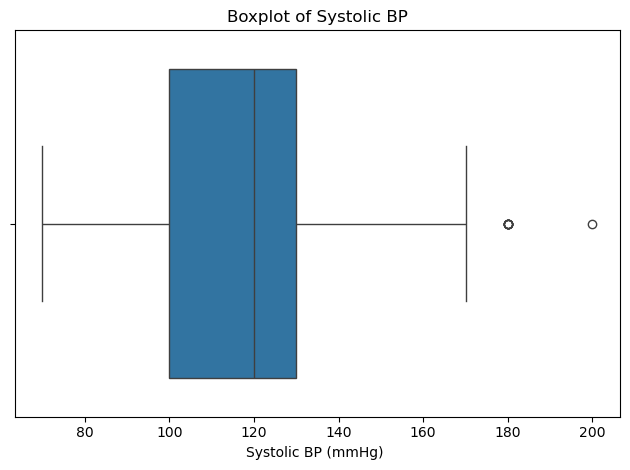

In [85]:
sns.boxplot(x=df['Systolic BP'])
plt.title("Boxplot of Systolic BP")
plt.xlabel("Systolic BP (mmHg) ")
plt.tight_layout()
plt.show()

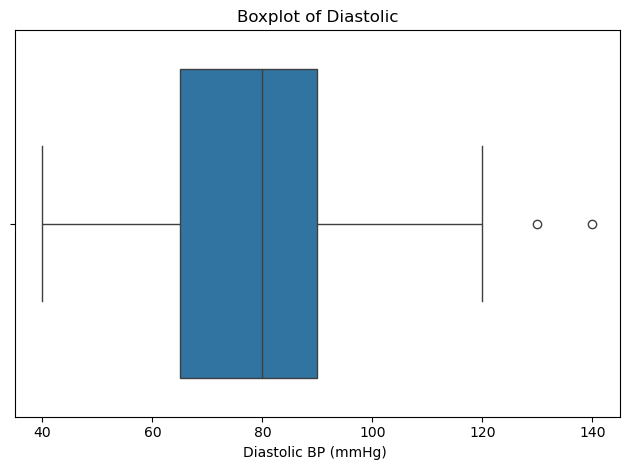

In [86]:
sns.boxplot(x=df['Diastolic'])
plt.title("Boxplot of Diastolic")
plt.xlabel("Diastolic BP (mmHg) ")
plt.tight_layout()
plt.show()

In [87]:
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 3 * IQR) & (df[col] <= Q3 + 3 * IQR)]

In [88]:
df.shape

(1100, 12)

In [89]:
df["PulsePressure"] = df["Systolic BP"] - df["Diastolic"]
# MAP: Mean Arterial Pressure - estimates the avverage blood pressure during one cardiac cycle
df["MAP"]           = (df["Systolic BP"] + 2 * df["Diastolic"]) / 3
# Diabete risk score
df["DiabetesRisk"]  = df["Preexisting Diabetes"] + df["Gestational Diabetes"]
# Split into age groups
df["AgeGroup"]      = pd.cut(df["Age"], bins=[0,20,30,40,100],
                              labels=["Teen","Young Adult","Adult","Mature"])
# Encode age group
df["AgeGroupEnc"]   = LabelEncoder().fit_transform(df["AgeGroup"].astype(str))

In [90]:
features = [
    "Age", "Systolic BP", "Diastolic", "BS", "Body Temp", "BMI", "Heart Rate",
    "Previous Complications", "Preexisting Diabetes", "Gestational Diabetes",
    "Mental Health", "PulsePressure", "MAP", "DiabetesRisk", "AgeGroupEnc",
]

df = df.drop_duplicates(subset=features)
df.reset_index(drop=True, inplace=True)

In [91]:
df.shape

(1081, 17)

### Encode Target

In [92]:
le = LabelEncoder()
df['RiskEncoded'] = le.fit_transform(df['Risk Level'])
label_map = {int(i): c for i, c in enumerate(le.classes_)}
label_map

{0: 'high', 1: 'low'}

### Train Test Split

In [93]:
X = df[features]
y = df['RiskEncoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9, stratify=y
)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [94]:
X_train.shape

(864, 15)

In [95]:
X_test.shape

(217, 15)

In [96]:
models = {
    'Random Forest': (
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,           # prevents unlimited depth
            min_samples_leaf=5,     # each leaf needs ≥5 samples
            min_samples_split=10,   # each split needs ≥10 samples
            random_state=9,
        ),
        X_train, X_test,
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=150,
            max_depth=4,            # slightly deeper than default
            min_samples_leaf=5,
            subsample=0.8,          # stochastic: use 80% of data per tree
            random_state=9,
        ),
        X_train, X_test,
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=9),  # L2 by default
        X_train_s, X_test_s,
    ),
}

In [98]:
results = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds      = model.predict(Xte)
    train_acc  = accuracy_score(y_train, model.predict(Xtr))
    test_acc   = accuracy_score(y_test,  preds)
    gap        = train_acc - test_acc
    cv_scores  = cross_val_score(model, Xtr, y_train, cv=5, scoring="accuracy")
    report     = classification_report(y_test, preds, target_names=le.classes_, output_dict=True)
    cm         = confusion_matrix(y_test, preds).tolist()
 
    results[name] = {
        'train_acc': round(float(train_acc) * 100, 2),
        'test_acc':  round(float(test_acc)  * 100, 2),
        'gap':       round(float(gap)        * 100, 2),
        'cv_mean':   round(float(cv_scores.mean()) * 100, 2),
        'cv_std':    round(float(cv_scores.std())  * 100, 2),
        'report':    report,
        'cm':        cm,
    }
    status = "✓ Clean" if abs(gap) < 0.02 else ("⚠ Minor" if abs(gap) < 0.05 else "✗ Overfit")

In [99]:
cv_scores.mean()

np.float64(0.9710512165613657)

In [100]:
cv_scores.std()

np.float64(0.01101732155171077)

In [101]:
rf_model    = models['Random Forest'][0]
importances = {f: round(float(v)*100,2) for f,v in zip(features, rf_model.feature_importances_)}
best_model  = max(results, key=lambda k: results[k]['test_acc'])

In [102]:
print(f"\n  Best model : {best_model} @ {results[best_model]['test_acc']}% test accuracy")
print(f"\n  Feature importances (top 10, RF):")


  Best model : Gradient Boosting @ 99.08% test accuracy

  Feature importances (top 10, RF):


In [105]:
for feat, imp in sorted(importances.items(), key=lambda x: -x[1]):
    print(f"{feat:<30} {imp:5.2f}%  {'█'*int(imp/1.5)}")

DiabetesRisk                   31.31%  ████████████████████
Heart Rate                     11.25%  ███████
BS                             11.10%  ███████
BMI                            10.88%  ███████
Preexisting Diabetes           10.59%  ███████
Mental Health                  10.33%  ██████
Gestational Diabetes            4.48%  ██
Previous Complications          4.04%  ██
MAP                             1.79%  █
Systolic BP                     1.37%  
Diastolic                       1.33%  
Age                             0.79%  
PulsePressure                   0.32%  
Body Temp                       0.29%  
AgeGroupEnc                     0.13%  


In [110]:
output = dict(
    n_rows=len(df), removed_dupes=1081, n_features=len(features),
    features=features, classes=le.classes_.tolist(), label_map=label_map,
    results=results, importances=importances, best_model=best_model,
)
with open('H.E.A.R.T_results.json', 'w') as f:
    json.dump(output, f, indent=2, cls=NpEncoder)
print(f"\n  Saved: {'H.E.A.R.T_results.json'}")


  Saved: H.E.A.R.T_results.json
